In [70]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

In [71]:
load_dotenv()

True

In [72]:
class SubState(TypedDict):
    input_text: str
    translated_text: str

In [73]:
subgraph_llm = ChatOpenAI(model='gpt-4o')

In [74]:
def translate_text(state: SubState):
    prompt = f"""
    Translate the following text to Hindi.
    Keep it natural and clear. Do not add extra content.

    Text:
    {state["input_text"]}
    """.strip()

    translated_text = subgraph_llm.invoke(prompt).content
    return {'translated_text': translated_text}

In [75]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [76]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str

In [77]:
parent_llm = ChatOpenAI(model = 'gpt-5-nano')

In [78]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [79]:
def translate_answer(state: ParentState):
    # call the subgraph
    result = subgraph.invoke({'input_text': state['answer_eng']})
    return {'answer_hin': result['translated_text']}

In [80]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

In [81]:
graph = parent_builder.compile()

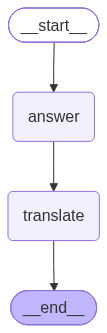

In [82]:
graph

In [83]:
result = graph.invoke({'question': 'What is quantum physics'})

In [84]:
result

{'question': 'What is quantum physics',
 'answer_eng': 'Quantum physics is the branch of physics that describes how nature behaves at the smallest scales, like atoms and subatomic particles, where the rules of everyday experience don’t apply.\n\nKey ideas:\n- Quantization: many properties come in discrete units (e.g., energy levels in atoms).\n- Wave-particle duality: particles can behave both like particles and like waves.\n- Superposition: systems can exist in multiple states at once until measured.\n- Entanglement: distant particles can have linked properties that are correlated in ways classical physics can’t explain.\n- Uncertainty: certain pairs of properties cannot be known precisely at the same time; nature is inherently probabilistic at small scales.\n\nHow it works (in a nutshell):\n- The state of a system is described by a wavefunction (ψ).\n- The wavefunction evolves according to the Schrödinger equation.\n- Observables (like position, momentum) are tied to mathematical ope